Harika! Şimdi UCB'den sonra geldin:

## 🟣 **Thompson Sampling**

Bu da yine **Multi-Armed Bandit (çok kollu kumarcı)** problemini çözen, ama **olasılıksal (Bayesyen)** bir yöntem.

UCB, deterministik bir şekilde (kesin kurallarla) “ortalama + belirsizlik” hesaplıyordu.
Thompson Sampling ise her bir seçeneğin **başarılı olma ihtimaline göre rastgele seçim yapar** — bu onu çok güçlü ve esnek yapar.

---

## 🎰 Bandit Problemi Hatırlatma

Yine 10 reklam var (veya 10 kola sahip slot makinesi gibi düşünebilirsin).
Ama kazandırma olasılıklarını **bilmiyoruz**.
Her adımda birini seçiyoruz ve tıklanıp tıklanmadığına göre öğreniyoruz.

---

## 🧠 Thompson Sampling Ne Yapar?

Her reklam için (veya her kol için):

* Bir **olasılık dağılımı** tutar → Beta dağılımı (`Beta(a, b)`)
* `a`: o reklamın **kaç kez tıklama aldığı** (başarı)
* `b`: o reklamın **kaç kez tıklama almadığı** (başarısızlık)

### Her turda şunu yapar:

1. **Her reklam için** `Beta(a, b)` dağılımından **rastgele bir sayı çeker**
2. En yüksek değeri çeken reklamı seçer
3. Sonuç tıklanmışsa → `a += 1`, tıklanmamışsa → `b += 1`

---

### 🔁 Böylece:

* Daha çok kazandıran reklamın dağılımı sağa kayar → daha çok seçilir
* Ama arada **şansa dayalı keşif de yapar**
* Bu yöntem, **explore-exploit** dengesini çok zarif şekilde kurar

---

## 🎯 UCB vs Thompson Sampling

| Kriter             | UCB                           | Thompson Sampling                                |
| ------------------ | ----------------------------- | ------------------------------------------------ |
| Seçim tarzı        | Deterministik (kesin)         | Olasılıksal (rastgele örnekleme)                 |
| Güvenlik katsayısı | Var (log hesaplı belirsizlik) | Yok, ama dağılım üzerinden zaten belirsizlik var |
| Explore / Exploit  | Belirli kurallarla ayrılır    | Dağılım sayesinde otomatik ve yumuşak            |
| Genelde tercih     | Basit sistemler               | Gerçek hayatta daha başarılı                     |

---

## 📊 Python'da Temel Yapı

```python
import random

N = 10000  # toplam tur (kullanıcı)
d = 10     # toplam reklam sayısı

ads_selected = []
numbers_of_rewards_1 = [0] * d  # Başarı sayısı (tıklama)
numbers_of_rewards_0 = [0] * d  # Başarısızlık sayısı (tıksız)

total_reward = 0

for n in range(0, N):
    ad = 0
    max_random = 0
    for i in range(0, d):
        # Beta dağılımından örnek çek (olasılık)
        random_beta = random.betavariate(numbers_of_rewards_1[i] + 1,
                                         numbers_of_rewards_0[i] + 1)
        if random_beta > max_random:
            max_random = random_beta
            ad = i
    
    ads_selected.append(ad)
    
    reward = dataset.values[n, ad]  # 0 veya 1
    if reward == 1:
        numbers_of_rewards_1[ad] += 1
    else:
        numbers_of_rewards_0[ad] += 1

    total_reward += reward
```

---

## 🧮 Beta Dağılımı Nedir?

* `Beta(a, b)` → 0 ile 1 arasında bir dağılım
* Başarı sayısı arttıkça eğri sağa kayar → daha yüksek değer üretir
* Tıklama almayanlarda dağılım sola yaslanır

---

## ✅ Avantajları

| Güçlü Yanlar     | Açıklama                                 |
| ---------------- | ---------------------------------------- |
| Hızlı ve verimli | Pratikte UCB’den daha iyi sonuçlar verir |
| Olasılıksal      | Exploration (keşif) doğal şekilde oluşur |
| Bayesyen temelli | Veri geldikçe dağılım güncellenir        |
| Sürekli öğrenme  | Statik değil, dinamik seçim yapar        |

---

## 🎓 Özet

| Özellik        | Açıklama                                      |
| -------------- | --------------------------------------------- |
| Konu           | Çok kollu bandit çözümü                       |
| Yöntem         | Bayesyen – Beta dağılımı örneklemesi          |
| Seçim tarzı    | Rastgele ama dağılıma dayalı                  |
| Uygulama alanı | Reklam seçimi, öneri sistemleri, A/B testleri |

---

Eğitimde bu kodun performansını muhtemelen **UCB ile karşılaştıracaklar**.
İstersen seninle UCB ve Thompson Sampling grafiklerini yan yana çizebiliriz.

Hazırsan eğitim sonrası kodları birlikte analiz ederiz!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')

In [4]:
import random
N = 10000
d = 10
ads_selected = []
numbers_of_rewards_1 = [0] * d
numbers_of_rewards_0 = [0] * d
total_reward = 0
for n in range(0, N):
    ad = 0
    max_random = 0
    for i in range(0, d):
        random_beta = random.betavariate(numbers_of_rewards_1[i] + 1, numbers_of_rewards_0[i] + 1)
        if random_beta > max_random:
            max_random = random_beta
            ad = i
    ads_selected.append(ad)
    reward = dataset.values[n, ad]
    if reward == 1:
        numbers_of_rewards_1[ad] = numbers_of_rewards_1[ad] + 1
    else:
        numbers_of_rewards_0[ad] = numbers_of_rewards_0[ad] + 1
    total_reward = total_reward + reward

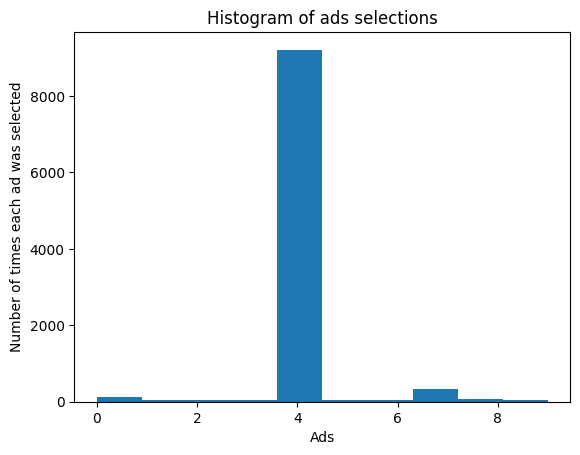

In [5]:
plt.hist(ads_selected)
plt.title('Histogram of ads selections')
plt.xlabel('Ads')
plt.ylabel('Number of times each ad was selected')
plt.show()